In [2]:
from AgentBasedModel import *
from AgentBasedModel.params_calibration.utils_calibration import *
from AgentBasedModel.params_calibration.calibrationv2.utils_calibration_v2 import *
import random
import numpy as np
import optuna

In [3]:
# всякие константы для обучения
N_RUNS = 4
N_TICKS = 1000
CASH = 10 ** 3
EXCHANGE_VOLUME = 1000

target_params = pd.read_csv('mean_std_ethusdt_validation_data2.csv')
NORM_COEF_LR = 1 / target_params.loc[target_params["param"] == 'mean_on_ret2', "mean"].iloc[0]

In [4]:
# метрика лосса: mae где нормировка по корню дисперсии: самое научное, что я придумал/нашел
# + байесовское обучение оптуной, все диапазоны я выбрал интуитивно руководствуясь логикой/статьями
def loss_mae(t_params, m_params):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret"]
    arrs = ["autocorrelation_on_ret", "autocorrelation_on_abs_ret"]
    error = 0
    for i in arrs:
        m_params[i] = m_params[i].mean()
    for i in num + arrs:
        error += abs((t_params.loc[t_params["param"] == i, "mean"].iloc[0] - m_params[i]) / t_params.loc[t_params["param"] == i, "std"].iloc[0])
    return error / len(num + arrs)

def objective(trial):
    params = {
        'Random': trial.suggest_int('Random', 5, 100),
        'Fundamentalist': trial.suggest_int('Fundamentalist', 5, 100),
        'Chartist': trial.suggest_int('Chartist', 5, 100),
        'Universalist': trial.suggest_int('Universalist', 5, 100),
        'MarketMaker': trial.suggest_int('MarketMaker', 0, 1),
        'Transaction_cost': trial.suggest_float("Transaction_cost", 1e-4, 1e-1, log=True),
        'Std':  trial.suggest_float("Std", 1e-1, 1e2, log=True),
        'Std_Random':  trial.suggest_float("Std_Random", 1e-2, 1e1, log=True),
        'Avg_Traders': trial.suggest_float("Avg_Traders", -5, 0),
        'Last_Step': trial.suggest_float("Last_Step", 0, 1),
        'Last_Ret': trial.suggest_float("Last_Ret", 1e-3, 50, log=True),
        'Noisy_Level': trial.suggest_float("Noisy_Level", 1e-3, 5, log=True)
    }
    errors = []

    for run_idx in range(N_RUNS):
        random.seed(42 + run_idx)
        np.random.seed(42 + run_idx)

        try:
            exchange = ExchangeAgent(std=params['Std'], transaction_cost=params['Transaction_cost'], std_random=params['Std_Random'], divs_drifted=True)
            simulator2 = Simulator(**{
                'exchange': exchange,
                'traders': [
                    *[Random(exchange, CASH) for _ in range(params['Random'])],
                    *[Fundamentalist(exchange, CASH) for _ in range(params['Fundamentalist'])],
                    *[Chartist(exchange, CASH) for _ in range(params['Chartist'])],
                    *[Universalist(exchange, CASH) for _ in range(params['Universalist'])],
                    *[MarketMaker(exchange, CASH) for _ in range(params['MarketMaker'])],
                ],
            }, avg_traders=params['Avg_Traders'], last_step=params['Last_Step'], last_ret=params['Last_Ret'], noisy_level=params['Noisy_Level'], norm_coef_lr=NORM_COEF_LR)

            simulator2.simulate(N_TICKS, silent=True)
            prices = np.array(simulator2.info.prices)
            model_params = pipeline(prices, is_print=0)
            errors.append(loss_mae(target_params, model_params))
        except Exception:
            continue

    if len(errors) != N_RUNS:
        return 1000
    return float(np.mean(errors))

In [ ]:
# само обучение
study = optuna.create_study(study_name="calibration_mae_v2 (Exception fixed)", direction="minimize", storage="sqlite:///calibration_mae_2.db",  load_if_exists=True)
study.optimize(objective, show_progress_bar=True, n_trials=500)

best_params = study.best_params
best_score = study.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

[I 2026-03-29 22:08:29,600] A new study created in RDB with name: calibration_mae_v2 (Exception fixed)
Best trial: 0. Best value: 13.2412:   0%|          | 1/500 [00:11<1:38:11, 11.81s/it]

[I 2026-03-29 22:08:41,405] Trial 0 finished with value: 13.241175227813804 and parameters: {'Random': 88, 'Fundamentalist': 52, 'Chartist': 18, 'Universalist': 55, 'MarketMaker': 0, 'Transaction_cost': 0.0021122407319378324, 'Std': 0.19776166025590078, 'Std_Random': 1.4141208183237375, 'Avg_Traders': -1.3935259462297012, 'Last_Step': 0.30505783973238854, 'Last_Ret': 0.18335672157672703, 'Noisy_Level': 3.1286052524451473}. Best is trial 0 with value: 13.241175227813804.


Best trial: 1. Best value: 11.8368:   0%|          | 2/500 [00:29<2:07:46, 15.39s/it]

[I 2026-03-29 22:08:59,311] Trial 1 finished with value: 11.836781804659218 and parameters: {'Random': 62, 'Fundamentalist': 70, 'Chartist': 83, 'Universalist': 38, 'MarketMaker': 1, 'Transaction_cost': 0.0001075188082293562, 'Std': 4.243502138482543, 'Std_Random': 2.185281410653061, 'Avg_Traders': -0.8105261924940255, 'Last_Step': 0.8671278214982185, 'Last_Ret': 0.0025966113190492054, 'Noisy_Level': 0.015024568054441198}. Best is trial 1 with value: 11.836781804659218.


Best trial: 2. Best value: 10.5462:   1%|          | 3/500 [01:32<5:05:17, 36.86s/it]

...

[I 2026-03-29 23:23:10,116] Trial 363 finished with value: 0.5931299552279177 and parameters: {'Random': 95, 'Fundamentalist': 26, 'Chartist': 100, 'Universalist': 9, 'MarketMaker': 1, 'Transaction_cost': 0.004153230786203267, 'Std': 1.1795964708545024, 'Std_Random': 0.14756577440503005, 'Avg_Traders': -4.0637387814646475, 'Last_Step': 0.020953395347130782, 'Last_Ret': 0.049760642383610665, 'Noisy_Level': 0.017043769527429007}. Best is trial 246 with value: 0.5079830954342969.


Best trial: 246. Best value: 0.507983:  73%|███████▎  | 365/500 [1:14:58<45:05, 20.04s/it]

[I 2026-03-29 23:23:28,226] Trial 364 finished with value: 0.7634556515160877 and parameters: {'Random': 92, 'Fundamentalist': 26, 'Chartist': 98, 'Universalist': 9, 'MarketMaker': 1, 'Transaction_cost': 0.0036820395178903164, 'Std': 1.2557306524834622, 'Std_Random': 0.11359602833225206, 'Avg_Traders': -4.065871102500715, 'Last_Step': 0.02308295222846775, 'Last_Ret': 0.084035655182408, 'Noisy_Level': 0.0011357531587360074}. Best is trial 246 with value: 0.5079830954342969.


Best trial: 246. Best value: 0.507983:  73%|███████▎  | 366/500 [1:15:19<45:24, 20.33s/it]

[I 2026-03-29 23:23:49,227] Trial 365 finished with value: 0.7616358886379764 and parameters: {'Random': 95, 'Fundamentalist': 37, 'Chartist': 100, 'Universalist': 5, 'MarketMaker': 1, 'Transaction_cost': 0.0028628763574971698, 'Std': 1.154661006227542, 'Std_Random': 0.09511406393212944, 'Avg_Traders': -3.9957371369581782, 'Last_Step': 0.04989044536592141, 'Last_Ret': 0.05133052996910918, 'Noisy_Level': 0.021156278852530058}. Best is trial 246 with value: 0.5079830954342969.


[I 2026-03-30 11:21:13,129] Using an existing study with name 'calibration_mae_v2 (Exception fixed)' instead of creating a new one.
C:\Users\rodion\AppData\Local\Temp\ipykernel_23152\2643285881.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


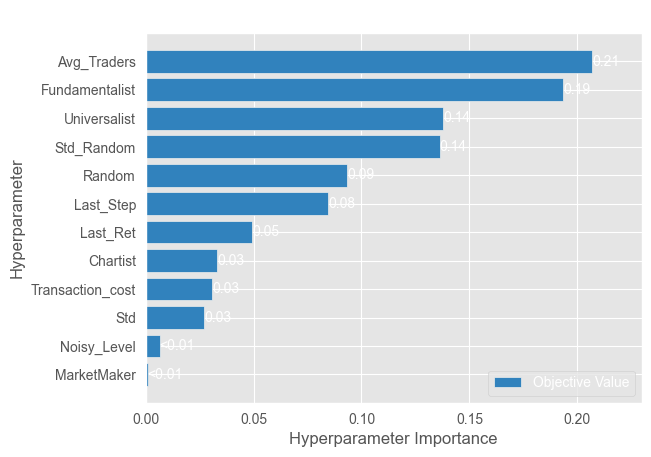

In [3]:
from optuna.visualization.matplotlib import plot_param_importances
import sklearn

study = optuna.create_study(study_name="calibration_mae_v2 (Exception fixed)", direction="minimize", storage="sqlite:///calibration_mae_2.db",  load_if_exists=True)
plot_param_importances(study)
plt.show()

In [4]:
best_params = study.best_params
best_score = study.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

Best params: {'Random': 88, 'Fundamentalist': 22, 'Chartist': 93, 'Universalist': 9, 'MarketMaker': 1, 'Transaction_cost': 0.0022981155967713687, 'Std': 1.8056343332129268, 'Std_Random': 0.267108036227016, 'Avg_Traders': -3.5964758067865086, 'Last_Step': 0.045229432640877434, 'Last_Ret': 0.0327595207014759, 'Noisy_Level': 0.034104972885075635}
Best Score: 0.44340689999743343
